# 12 — LSTM vs Default Sweep

Five figures comparing the Phase 12 LSTM (`results/lstm/...`) against the
full-set tabular sweep (`results/predictions`, `results/metrics`). The LSTM
is trained on the **full 12-month-per-year target set** (`winter_only_training: false`)
so this is a clean apples-to-apples comparison against the default sweep.

Inputs:
- `results/predictions/pooled_allLeads.nc` + `results/metrics/metrics_allLeads.csv` (default sweep)
- `results/lstm/predictions/pooled_allLeads.nc` + `results/lstm/metrics/metrics_allLeads.csv` (LSTM run)

Outputs (under `results/figures/12_lstm_vs_default/`):
- `fig01_headline_metrics.{pdf,png}` — RMSE / MAE / Pearson r / ACC / MSSS-vs-clim, models × leads
- `fig02_lead_degradation.{pdf,png}` — RMSE & MSSS as a function of lead
- `fig03_msss_skill_maps_with_lstm.{pdf,png}` — per-cell MSSS, with LSTM panel added
- `fig04_pred_vs_truth_extremes.{pdf,png}` — scatter restricted to `|y_truth| > 1.0`
- `fig05_pod_far_extremes.{pdf,png}` — categorical extremes (POD vs FAR) at SPEI3 < −1.0

Each figure has a `· LSTM vs default` suffix in the suptitle so the rendered
PDFs can sit next to the per-experiment `09_paper_figures*` outputs without
confusion.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl

from droughtmodel.utils import RESULTS_DIR

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'legend.fontsize':   9,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'figure.dpi':        120,
    'savefig.bbox':      'tight',
    'savefig.dpi':       200,
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
})

FIG_DIR = RESULTS_DIR / 'figures' / '12_lstm_vs_default'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_PRED_PATH = RESULTS_DIR / 'predictions' / 'pooled_allLeads.nc'
DEFAULT_METR_PATH = RESULTS_DIR / 'metrics'     / 'metrics_allLeads.csv'
LSTM_PRED_PATH    = RESULTS_DIR / 'lstm' / 'predictions' / 'pooled_allLeads.nc'
LSTM_METR_PATH    = RESULTS_DIR / 'lstm' / 'metrics'     / 'metrics_allLeads.csv'

def _save(fig, name):
    fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'wrote  {(FIG_DIR / name).relative_to(ROOT)}.{{pdf,png}}')

def _ttl(text):
    return f'{text}  ·  LSTM vs default'

print('output dir :', FIG_DIR.relative_to(ROOT))

output dir : results/figures/12_lstm_vs_default


In [2]:
# Load both runs. The LSTM file may not exist yet — guard so the notebook can
# be edited before exp_lstm has finished.
lstm_available = LSTM_PRED_PATH.exists() and LSTM_METR_PATH.exists()
if not lstm_available:
    print('LSTM outputs not found yet. Re-run this notebook after exp_lstm completes.')
    print(f'  expected: {LSTM_PRED_PATH.relative_to(ROOT)}')
    print(f'  expected: {LSTM_METR_PATH.relative_to(ROOT)}')

default_pred = xr.open_dataset(DEFAULT_PRED_PATH)
default_metr = pd.read_csv(DEFAULT_METR_PATH).assign(experiment='default')

# All ML models from the default sweep, plus climatology as the skill reference.
DEFAULT_ML = ['ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost']
TABULAR_BEST_BY_MSSS = None

# Identify the strongest tabular model on the headline lead (used for the
# extreme-target scatter and a few overlays).
HEADLINE_LEAD = 3 if 3 in default_metr['lead'].unique() else int(default_metr['lead'].median())
_best_row = (
    default_metr.query(
        "metric == 'msss_vs_climatology' and evaluation_window == 'winter_only' "
        "and fold == 'pooled' and lead == @HEADLINE_LEAD"
    )
    .query("model in @DEFAULT_ML")
    .sort_values('value', ascending=False)
)
if not _best_row.empty:
    TABULAR_BEST_BY_MSSS = _best_row.iloc[0]['model']
print(f'default headline lead = L{HEADLINE_LEAD}')
print(f'best tabular model by MSSS-vs-clim (winter pool): {TABULAR_BEST_BY_MSSS}')

# LSTM_LEADS_OK = the subset of leads whose LSTM predictions have any finite
# values. The 2026-06-30 run diverged to NaN at L=3 and L=6 (exploding gradients,
# fixed by adding grad_clip_norm=1.0 to the LSTM training loop) — every figure
# that overlays LSTM consults this set so a partially-bad run still produces
# the figures it CAN produce instead of crashing on empty arrays.
LSTM_LEADS_OK: set = set()
if lstm_available:
    lstm_pred = xr.open_dataset(LSTM_PRED_PATH)
    lstm_metr = pd.read_csv(LSTM_METR_PATH).assign(experiment='lstm')
    lstm_metr = lstm_metr.query("model == 'lstm'")
    metr = pd.concat([default_metr, lstm_metr], ignore_index=True)
    for L in sorted(lstm_pred['lead'].values.tolist()):
        if np.isfinite(lstm_pred['pred_lstm'].sel(lead=L).values).any():
            LSTM_LEADS_OK.add(int(L))
    bad = sorted(set(int(L) for L in lstm_pred['lead'].values) - LSTM_LEADS_OK)
    print('default vars     :', list(default_pred.data_vars))
    print('lstm vars        :', list(lstm_pred.data_vars))
    print(f'lstm leads usable: {sorted(LSTM_LEADS_OK)}')
    if bad:
        print(f'  WARNING: LSTM produced no finite predictions at L={bad}. '
              f'Likely cause: training divergence (loss → NaN/inf). Re-run after '
              f'enabling `grad_clip_norm` in configs/models/lstm.yaml.')
else:
    metr = default_metr.copy()
    lstm_pred = None

MODELS_FOR_COMP = [m for m in (DEFAULT_ML + ['lstm']) if m != 'lstm' or lstm_available]
print('models in comparison:', MODELS_FOR_COMP)


default headline lead = L3
best tabular model by MSSS-vs-clim (winter pool): rf


default vars     : ['pred_climatology', 'pred_persistence', 'pred_ar', 'pred_ols', 'pred_ridge', 'pred_lasso', 'pred_elasticnet', 'pred_rf', 'pred_xgboost', 'truth']
lstm vars        : ['pred_climatology', 'pred_persistence', 'pred_lstm', 'truth']
lstm leads usable: [1, 3, 6]
models in comparison: ['ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost', 'lstm']


## Fig 1 — Headline metrics, models × leads

Bar chart of the five headline metrics (RMSE, MAE, Pearson r, ACC, MSSS-vs-climatology)
across all tabular models + LSTM, faceted by lead. Errorbars are the bootstrap
95 % CIs already in the metrics CSV. Evaluation window: **winter pool**
(`evaluation_window == 'winter_only'`) — that's the headline season.

wrote  results/figures/12_lstm_vs_default/fig01_headline_metrics.{pdf,png}


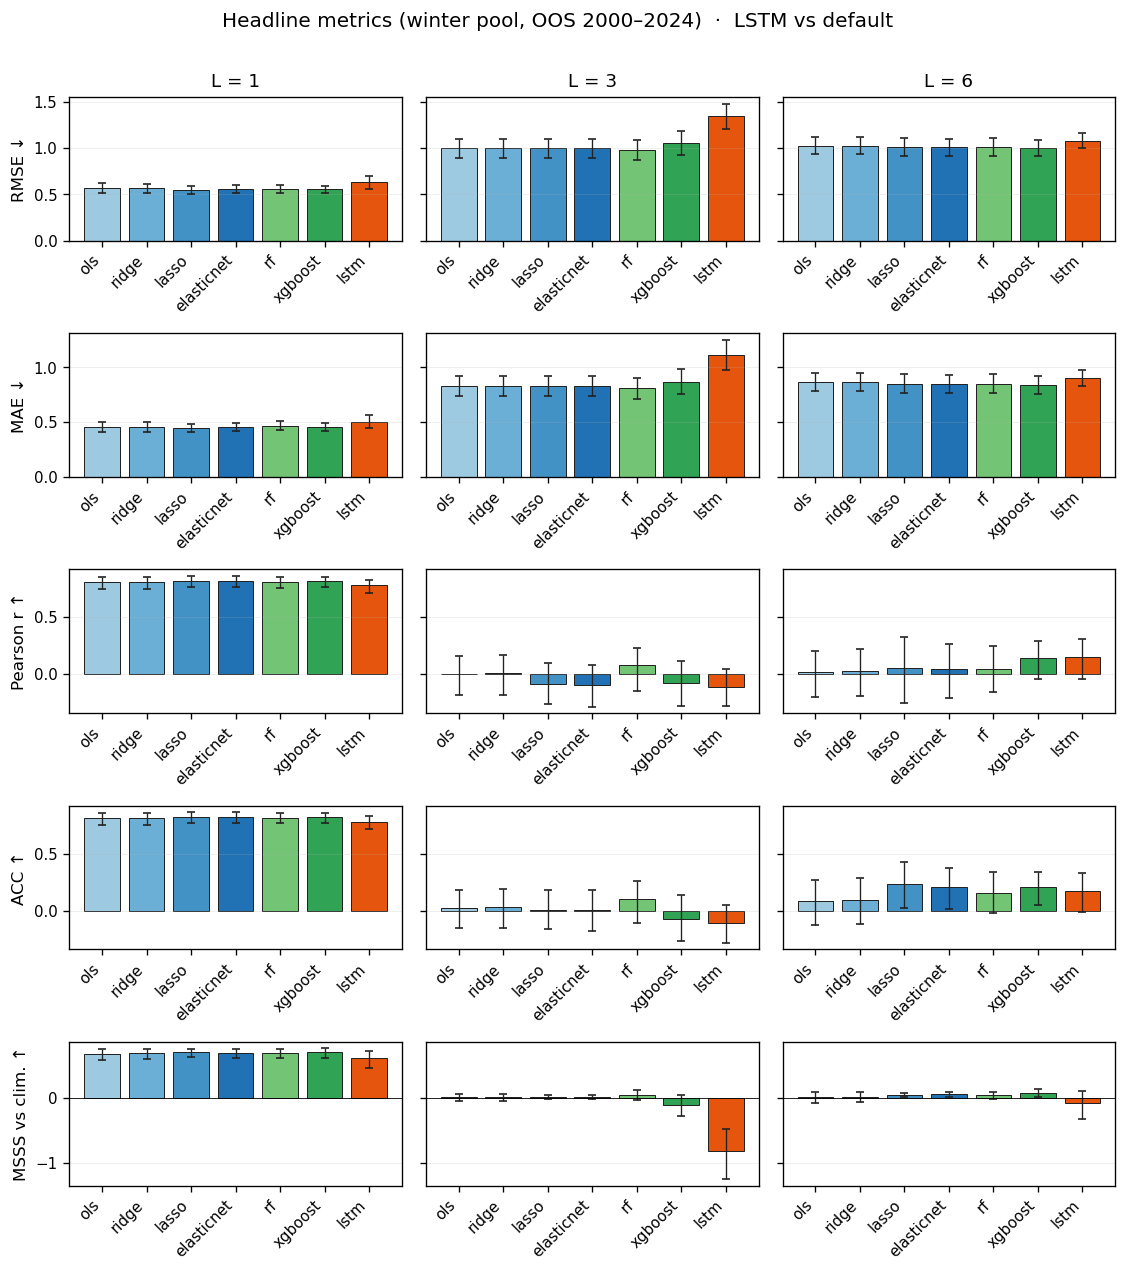

In [3]:
METRICS_ORDER = ['rmse', 'mae', 'pearson_r', 'acc', 'msss_vs_climatology']
METRIC_TITLES = {
    'rmse': 'RMSE',
    'mae': 'MAE',
    'pearson_r': 'Pearson r',
    'acc': 'ACC',
    'msss_vs_climatology': 'MSSS vs clim.',
}
LOWER_IS_BETTER = {'rmse', 'mae'}

leads = sorted(metr['lead'].unique())
n_metrics = len(METRICS_ORDER)
n_leads = len(leads)

fig, axes = plt.subplots(
    n_metrics, n_leads,
    figsize=(3.2 * n_leads, 2.1 * n_metrics),
    sharey='row',
)
if n_leads == 1:
    axes = axes[:, None]

# Model styling — LSTM gets a distinct red, tabular stays in muted blues/greens.
MODEL_COLORS = {
    'ols':        '#9ecae1',
    'ridge':      '#6baed6',
    'lasso':      '#4292c6',
    'elasticnet': '#2171b5',
    'rf':         '#74c476',
    'xgboost':    '#31a354',
    'lstm':       '#e6550d',
}

win_pool = metr.query("evaluation_window == 'winter_only' and fold == 'pooled' and model in @MODELS_FOR_COMP")

for r, met in enumerate(METRICS_ORDER):
    for c, L in enumerate(leads):
        ax = axes[r, c]
        sub = win_pool.query("metric == @met and lead == @L")
        sub = sub.set_index('model').reindex(MODELS_FOR_COMP)
        xs = np.arange(len(MODELS_FOR_COMP))
        colors = [MODEL_COLORS.get(m, '#888') for m in MODELS_FOR_COMP]
        ax.bar(xs, sub['value'].values, color=colors, edgecolor='#222', linewidth=0.6)
        err_low = sub['value'].values - sub['ci_lower'].values
        err_high = sub['ci_upper'].values - sub['value'].values
        ax.errorbar(xs, sub['value'].values,
                    yerr=np.vstack([err_low, err_high]),
                    fmt='none', ecolor='#222', capsize=2.5, linewidth=0.8)
        ax.set_xticks(xs)
        ax.set_xticklabels(MODELS_FOR_COMP, rotation=45, ha='right')
        if c == 0:
            arrow = ' ↓' if met in LOWER_IS_BETTER else ' ↑'
            ax.set_ylabel(METRIC_TITLES[met] + arrow)
        if r == 0:
            ax.set_title(f'L = {L}')
        ax.grid(axis='y', alpha=0.3, linewidth=0.4)
        if met in ('msss_vs_climatology', 'msss_vs_persistence'):
            ax.axhline(0, color='k', linewidth=0.5)

fig.suptitle(_ttl('Headline metrics (winter pool, OOS 2000–2024)'), y=1.005, fontsize=12)
fig.tight_layout()
_save(fig, 'fig01_headline_metrics')

## Fig 2 — Lead-time degradation curves

RMSE (lower-is-better) and MSSS-vs-climatology (higher-is-better) as a function
of lead. One line per model. The v12 hypothesis is that LSTM should degrade
more gracefully than tabular models at L = 6 (long-lead regime where SNR is
lowest).

wrote  results/figures/12_lstm_vs_default/fig02_lead_degradation.{pdf,png}


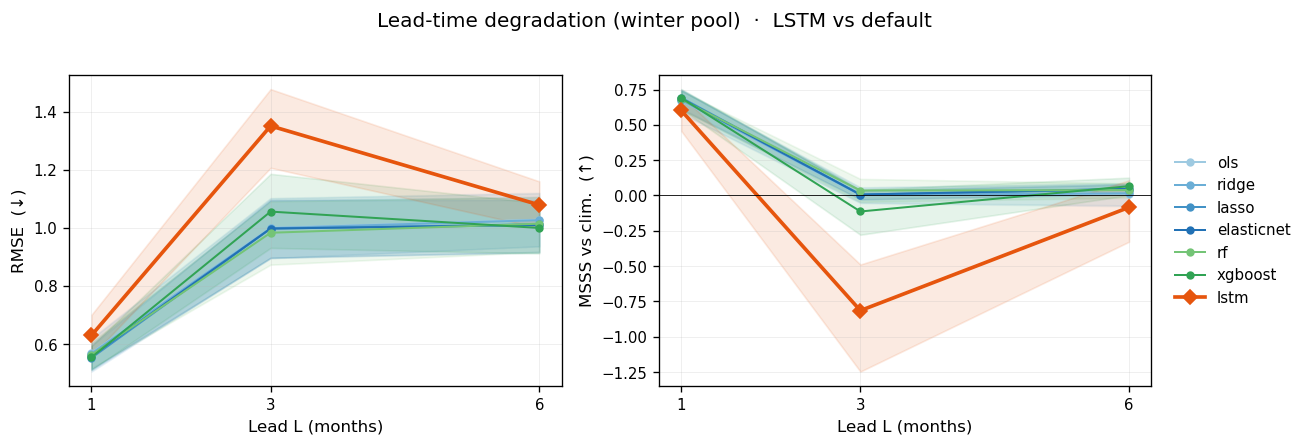

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)

for ax, met, title in [
    (axes[0], 'rmse', 'RMSE  (↓)'),
    (axes[1], 'msss_vs_climatology', 'MSSS vs clim.  (↑)'),
]:
    for m in MODELS_FOR_COMP:
        sub = win_pool.query("metric == @met and model == @m").sort_values('lead')
        if sub.empty:
            continue
        color = MODEL_COLORS.get(m, '#888')
        lw = 2.2 if m == 'lstm' else 1.2
        marker = 'D' if m == 'lstm' else 'o'
        ax.plot(sub['lead'], sub['value'], marker=marker, lw=lw,
                color=color, label=m, markersize=6 if m == 'lstm' else 4)
        ax.fill_between(sub['lead'], sub['ci_lower'], sub['ci_upper'],
                         color=color, alpha=0.12)
    ax.set_xlabel('Lead L (months)')
    ax.set_ylabel(title)
    ax.set_xticks(leads)
    ax.grid(alpha=0.3, linewidth=0.4)
    if met == 'msss_vs_climatology':
        ax.axhline(0, color='k', linewidth=0.5)

axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(_ttl('Lead-time degradation (winter pool)'), y=1.02, fontsize=12)
fig.tight_layout()
_save(fig, 'fig02_lead_degradation')

## Fig 3 — Per-cell MSSS spatial skill maps

Per-cell MSSS-vs-climatology for the LSTM and the best tabular model, computed
from the pooled OOS predictions. Same divergent RdBu_r colormap as the existing
spatial-skill maps (notebook 07) so the panels are directly comparable.

/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_962/2546419421.py:6: RuntimeWarning: Mean of empty slice
  mse_p = np.nanmean(pe, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_962/2546419421.py:7: RuntimeWarning: Mean of empty slice
  mse_c = np.nanmean(ce, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_962/2546419421.py:6: RuntimeWarning: Mean of empty slice
  mse_p = np.nanmean(pe, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_962/2546419421.py:7: RuntimeWarning: Mean of empty slice
  mse_c = np.nanmean(ce, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_962/2546419421.py:6: RuntimeWarning: Mean of empty slice
  mse_p = np.nanmean(pe, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_962/2546419421.py:7: RuntimeWarning: Mean of empty slice
  mse_c = np.nanmean(ce, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_962/2546419421.py:52: UserWarning: This figure 

wrote  results/figures/12_lstm_vs_default/fig03_msss_skill_maps_with_lstm.{pdf,png}


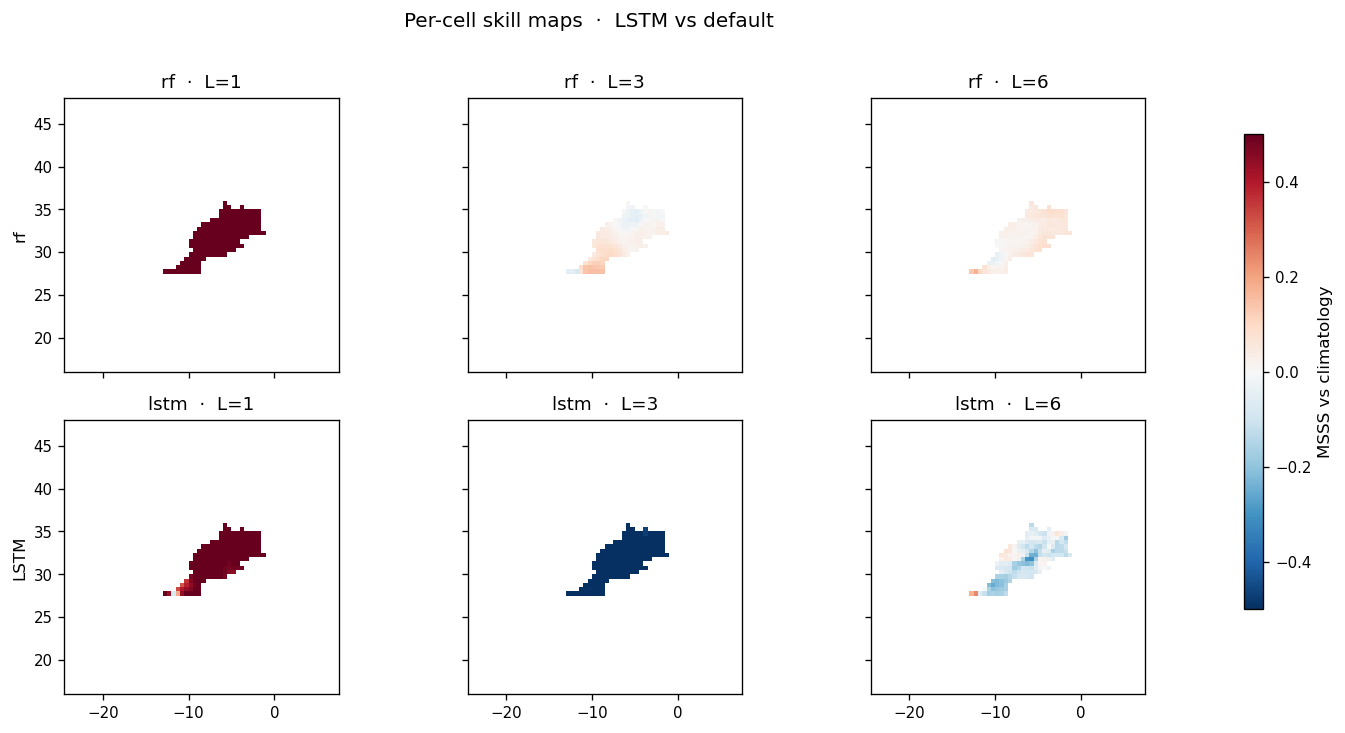

In [5]:
def _per_cell_msss_vs_clim(pred, truth, clim):
    """MSSS = 1 - MSE(pred) / MSE(clim), per (lat, lon)."""
    finite = np.isfinite(pred) & np.isfinite(truth) & np.isfinite(clim)
    pe = np.where(finite, (pred - truth) ** 2, np.nan)
    ce = np.where(finite, (clim - truth) ** 2, np.nan)
    mse_p = np.nanmean(pe, axis=0)
    mse_c = np.nanmean(ce, axis=0)
    return 1.0 - mse_p / np.where(mse_c > 0, mse_c, np.nan)

def _winter_slice(ds):
    months = pd.DatetimeIndex(ds['time'].values).month
    return ds.isel(time=np.where(np.isin(months, [11, 12, 1, 2]))[0])

if lstm_available and TABULAR_BEST_BY_MSSS is not None:
    fig, axes = plt.subplots(2, n_leads, figsize=(3.6 * n_leads, 6.0),
                             sharex=True, sharey=True)
    if n_leads == 1:
        axes = axes[:, None]
    cmap = mpl.colormaps.get_cmap('RdBu_r')
    vmin, vmax = -0.5, 0.5
    for c, L in enumerate(leads):
        d_w = _winter_slice(default_pred.sel(lead=L))
        l_w = _winter_slice(lstm_pred.sel(lead=L))
        clim_arr = d_w['pred_climatology'].values
        truth_arr = d_w['truth'].values

        best_tab = d_w[f'pred_{TABULAR_BEST_BY_MSSS}'].values
        lstm_arr = l_w['pred_lstm'].values

        m_tab = _per_cell_msss_vs_clim(best_tab, truth_arr, clim_arr)
        # LSTM truth/clim arrays must match the lstm file's stitched time axis.
        clim_arr_l = l_w['pred_climatology'].values
        truth_arr_l = l_w['truth'].values
        m_lstm = _per_cell_msss_vs_clim(lstm_arr, truth_arr_l, clim_arr_l)

        ax_tab, ax_lstm = axes[0, c], axes[1, c]
        for ax, arr, title in [
            (ax_tab,  m_tab,  f'{TABULAR_BEST_BY_MSSS}  ·  L={L}'),
            (ax_lstm, m_lstm, f'lstm  ·  L={L}'),
        ]:
            im = ax.pcolormesh(default_pred['lon'].values, default_pred['lat'].values,
                               arr, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
            ax.set_title(title)
            ax.set_aspect('equal')
        if c == 0:
            axes[0, c].set_ylabel(TABULAR_BEST_BY_MSSS)
            axes[1, c].set_ylabel('LSTM')
    cbar_ax = fig.add_axes([1.005, 0.18, 0.015, 0.66])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('MSSS vs climatology')
    fig.suptitle(_ttl('Per-cell skill maps'), y=1.01, fontsize=12)
    fig.tight_layout()
    _save(fig, 'fig03_msss_skill_maps_with_lstm')
else:
    print('Fig 3 skipped (LSTM file or best-tabular reference unavailable).')

## Fig 4 — Pred-vs-truth scatter, EXTREME targets only

Restricted to `|y_truth| > 1.0` (one standardised SPEI3 σ) — the regime where
the weighted-MSE training was meant to help. LSTM vs the best tabular model.
The 1:1 line shows perfect calibration; flat-near-zero clouds indicate
regression-to-the-mean.

wrote  results/figures/12_lstm_vs_default/fig04_pred_vs_truth_extremes.{pdf,png}


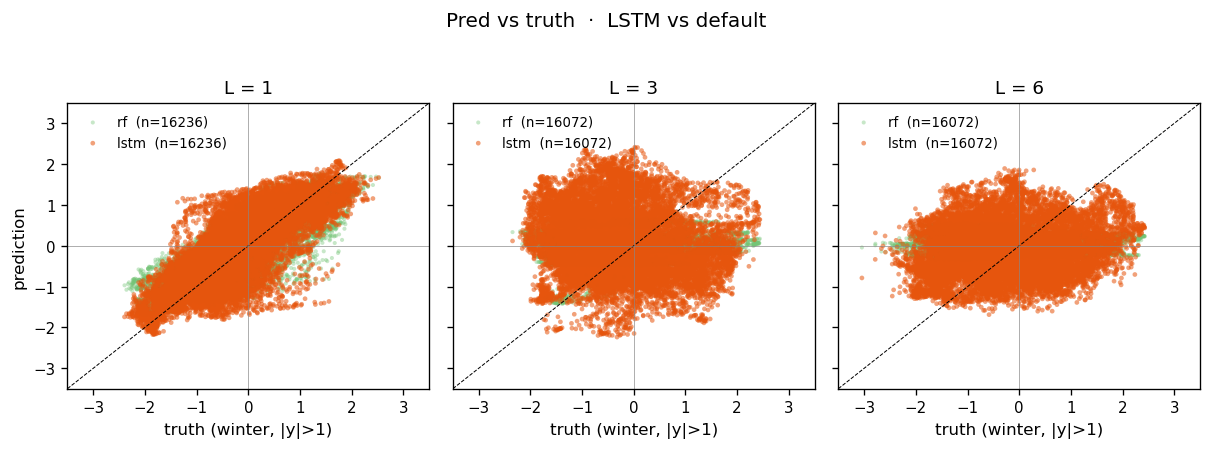

In [6]:
EXTREME_THRESHOLD = 0.0

def _winter_extreme_flat(ds, pred_name, threshold):
    """Flatten (time, lat, lon) winter-target pred/truth pairs to 1-D, filtered
    to |truth| > threshold and finite."""
    w = _winter_slice(ds)
    truth = w['truth'].values.ravel()
    pred = w[pred_name].values.ravel()
    mask = np.isfinite(truth) & np.isfinite(pred) & (np.abs(truth) > threshold)
    return pred[mask], truth[mask]

if lstm_available and TABULAR_BEST_BY_MSSS is not None:
    fig, axes = plt.subplots(1, n_leads, figsize=(3.4 * n_leads, 3.6), sharex=True, sharey=True)
    if n_leads == 1:
        axes = [axes]
    for c, L in enumerate(leads):
        ax = axes[c]
        p_tab, t_tab = _winter_extreme_flat(default_pred.sel(lead=L), f'pred_{TABULAR_BEST_BY_MSSS}', EXTREME_THRESHOLD)
        p_lstm, t_lstm = _winter_extreme_flat(lstm_pred.sel(lead=L), 'pred_lstm', EXTREME_THRESHOLD)
        ax.scatter(t_tab, p_tab, s=6, alpha=0.4, color=MODEL_COLORS[TABULAR_BEST_BY_MSSS],
                   label=f'{TABULAR_BEST_BY_MSSS}  (n={len(t_tab)})', edgecolors='none')
        ax.scatter(t_lstm, p_lstm, s=8, alpha=0.55, color=MODEL_COLORS['lstm'],
                   label=f'lstm  (n={len(t_lstm)})', edgecolors='none')
        lo, hi = -3.5, 3.5
        ax.plot([lo, hi], [lo, hi], color='k', linewidth=0.6, linestyle='--')
        ax.axhline(0, color='#888', linewidth=0.4)
        ax.axvline(0, color='#888', linewidth=0.4)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_title(f'L = {L}')
        ax.set_xlabel('truth (winter, |y|>1)')
        if c == 0:
            ax.set_ylabel('prediction')
        ax.legend(loc='upper left', frameon=False, fontsize=8)
    fig.suptitle(_ttl('Pred vs truth'), y=1.03, fontsize=12) #on EXTREME targets
    fig.tight_layout()
    _save(fig, 'fig04_pred_vs_truth_extremes')
else:
    print('Fig 4 skipped (LSTM file or best-tabular reference unavailable).')

## Fig 5 — POD vs FAR at SPEI3 < −1.0 (categorical extremes)

Per-model **probability of detection** (POD = TP / (TP + FN)) vs **false-alarm
ratio** (FAR = FP / (FP + TP)) on the binary drought classification (truth <
−1.0). Upper-left corner = perfect. One marker per (model, lead). Same metric
as the existing Fig 11 in `09_paper_figures*`, here with LSTM added in red.

wrote  results/figures/12_lstm_vs_default/categorical_extremes.csv
wrote  results/figures/12_lstm_vs_default/fig05_pod_far_extremes.{pdf,png}


,model,lead,pod,far,tp,fp,fn
0,ols,1,0.384117,0.273749,1422,536,2280
1,ridge,1,0.377904,0.267923,1399,512,2303
2,lasso,1,0.348730,0.219468,1291,363,2411
3,elasticnet,1,0.358185,0.221831,1326,378,2376
4,rf,1,0.328741,0.222364,1217,348,2485
5,xgboost,1,0.381956,0.245061,1414,459,2288
6,climatology,1,0.000000,NaN,0,0,3702
7,persistence,1,0.542410,0.391331,2008,1291,1694
8,lstm,1,0.572393,0.384370,2119,1323,1583
9,ols,3,0.000000,NaN,0,0,3850


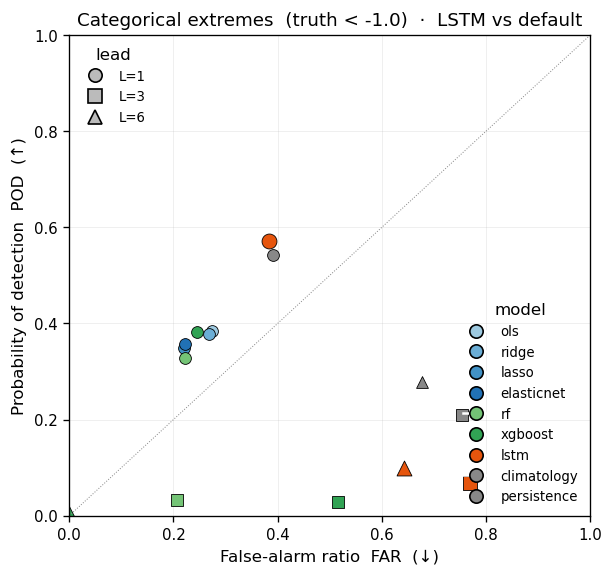

In [7]:
DROUGHT_THRESHOLD = -1.0

def _pod_far(pred, truth, thr):
    finite = np.isfinite(pred) & np.isfinite(truth)
    p, t = pred[finite], truth[finite]
    p_event = p < thr
    t_event = t < thr
    tp = int((p_event & t_event).sum())
    fp = int((p_event & ~t_event).sum())
    fn = int((~p_event & t_event).sum())
    pod = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    far = fp / (fp + tp) if (fp + tp) > 0 else np.nan
    return pod, far, tp, fp, fn

rows = []
for L in leads:
    d_w = _winter_slice(default_pred.sel(lead=L))
    truth = d_w['truth'].values.ravel()
    for m in DEFAULT_ML + ['climatology', 'persistence']:
        pred = d_w[f'pred_{m}'].values.ravel()
        pod, far, tp, fp, fn = _pod_far(pred, truth, DROUGHT_THRESHOLD)
        rows.append(dict(model=m, lead=L, pod=pod, far=far, tp=tp, fp=fp, fn=fn))
    if lstm_available:
        l_w = _winter_slice(lstm_pred.sel(lead=L))
        pod, far, tp, fp, fn = _pod_far(
            l_w['pred_lstm'].values.ravel(),
            l_w['truth'].values.ravel(),
            DROUGHT_THRESHOLD,
        )
        rows.append(dict(model='lstm', lead=L, pod=pod, far=far, tp=tp, fp=fp, fn=fn))
df_extreme = pd.DataFrame(rows)
df_extreme.to_csv(FIG_DIR / 'categorical_extremes.csv', index=False)
print(f'wrote  {(FIG_DIR / "categorical_extremes.csv").relative_to(ROOT)}')

fig, ax = plt.subplots(figsize=(5.6, 5.2))
MARKERS = {1: 'o', 3: 's', 6: '^'}
for _, row in df_extreme.iterrows():
    color = MODEL_COLORS.get(row['model'], '#888')
    marker = MARKERS.get(int(row['lead']), 'D')
    ax.scatter(row['far'], row['pod'], s=80 if row['model'] == 'lstm' else 50,
               color=color, marker=marker, edgecolor='k', linewidth=0.5,
               zorder=3 if row['model'] == 'lstm' else 2)
# Legends — separate for models and lead-markers
from matplotlib.lines import Line2D
model_handles = [
    Line2D([0], [0], marker='o', color='w', label=m,
           markerfacecolor=MODEL_COLORS.get(m, '#888'), markersize=8, markeredgecolor='k')
    for m in (DEFAULT_ML + (['lstm'] if lstm_available else []) + ['climatology', 'persistence'])
]
lead_handles = [
    Line2D([0], [0], marker=MARKERS[L], color='w', label=f'L={L}',
           markerfacecolor='#bbb', markersize=8, markeredgecolor='k') for L in leads
]
leg1 = ax.legend(handles=model_handles, loc='lower right', frameon=False, fontsize=8, title='model')
ax.add_artist(leg1)
ax.legend(handles=lead_handles, loc='upper left', frameon=False, fontsize=8, title='lead')

ax.plot([0, 1], [0, 1], color='#888', linewidth=0.6, linestyle=':')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('False-alarm ratio  FAR  (↓)')
ax.set_ylabel('Probability of detection  POD  (↑)')
ax.set_title(_ttl(f'Categorical extremes  (truth < {DROUGHT_THRESHOLD})'))
ax.grid(alpha=0.3, linewidth=0.4)
_save(fig, 'fig05_pod_far_extremes')
df_extreme

## Fig 6 — ACC vs lead (LSTM added)

Anomaly correlation coefficient as a function of lead, one line per model.
Mirrors the headline `fig01_acc_vs_lead` from `09_paper_figures.ipynb` but
adds LSTM in red. ACC is the SPEI3-anomaly correlation against truth — a
direct test of whether the model captures the *direction* of departures
from climatology, not just the magnitude.


wrote  results/figures/12_lstm_vs_default/fig06_acc_vs_lead.{pdf,png}


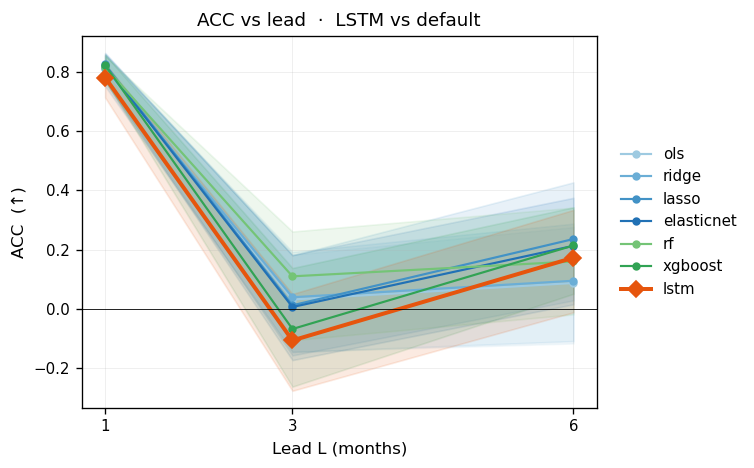

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
for m in MODELS_FOR_COMP:
    sub = win_pool.query("metric == 'acc' and model == @m").sort_values('lead')
    if sub.empty:
        continue
    color = MODEL_COLORS.get(m, '#888')
    lw = 2.4 if m == 'lstm' else 1.3
    marker = 'D' if m == 'lstm' else 'o'
    ax.plot(sub['lead'], sub['value'], marker=marker, lw=lw, color=color,
            label=m, markersize=7 if m == 'lstm' else 4)
    ax.fill_between(sub['lead'], sub['ci_lower'], sub['ci_upper'],
                     color=color, alpha=0.12)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Lead L (months)')
ax.set_ylabel('ACC  (↑)')
ax.set_xticks(leads)
ax.grid(alpha=0.3, linewidth=0.4)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_title(_ttl('ACC vs lead'))
fig.tight_layout()
_save(fig, 'fig06_acc_vs_lead')


## Fig 7 — Residual autocorrelation (white-noise test)

For each model, we compute residuals `(pred − truth)` averaged over Morocco
cells, then plot the autocorrelation up to 12-month lag. The 95 % white-noise
confidence band is `±1.96/√n`. If a model has *successfully* extracted the
temporal structure, residuals should look like white noise — ACF inside the
band at all lags. The LSTM hypothesis says it should reach white noise
*sooner* (smaller-magnitude ACF at lags 1-6) than the tabular models, which
ingest a fixed PACF-selected lag window and may leave residual lag-1
correlation behind.


/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_962/1399126962.py:9: RuntimeWarning: Mean of empty slice
  return np.nanmean(pred - truth, axis=(1, 2))


wrote  results/figures/12_lstm_vs_default/fig07_residual_acf.{pdf,png}


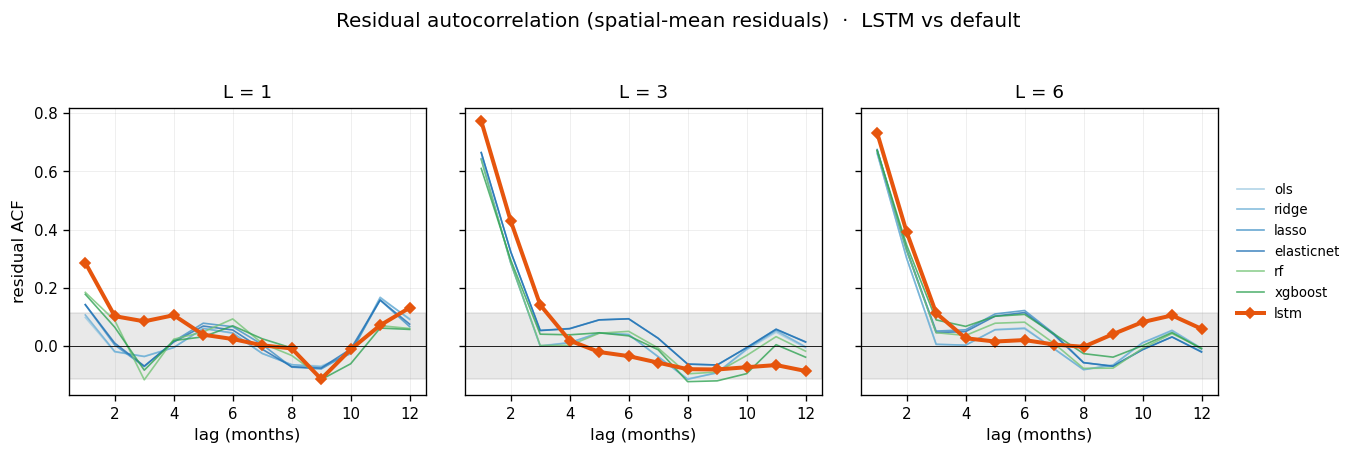

In [9]:
from statsmodels.tsa.stattools import acf

ACF_NLAGS = 12

def _spatial_mean_resid_series(ds, pred_name):
    truth = ds['truth'].values
    pred = ds[pred_name].values
    # Average residual over cells per timestep (NaN-safe).
    return np.nanmean(pred - truth, axis=(1, 2))

fig, axes = plt.subplots(1, n_leads, figsize=(3.8 * n_leads, 3.6), sharey=True)
if n_leads == 1:
    axes = [axes]
for c, L in enumerate(leads):
    ax = axes[c]
    d = default_pred.sel(lead=L)
    for m in DEFAULT_ML:
        s = _spatial_mean_resid_series(d, f'pred_{m}')
        s = s[np.isfinite(s)]
        if len(s) < ACF_NLAGS + 2:
            continue
        a = acf(s, nlags=ACF_NLAGS, fft=True)[1:]
        ax.plot(range(1, ACF_NLAGS + 1), a, color=MODEL_COLORS.get(m, '#888'),
                lw=1.0, alpha=0.8, label=m)
    if lstm_available:
        s = _spatial_mean_resid_series(lstm_pred.sel(lead=L), 'pred_lstm')
        s = s[np.isfinite(s)]
        if len(s) >= ACF_NLAGS + 2:
            a = acf(s, nlags=ACF_NLAGS, fft=True)[1:]
            ax.plot(range(1, ACF_NLAGS + 1), a, color=MODEL_COLORS['lstm'],
                    lw=2.4, marker='D', markersize=4, label='lstm')
            # 95% white-noise band: ±1.96 / sqrt(n)
            wn = 1.96 / np.sqrt(len(s))
            ax.axhspan(-wn, wn, color='#888', alpha=0.18)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel('lag (months)')
    if c == 0:
        ax.set_ylabel('residual ACF')
    ax.set_title(f'L = {L}')
    ax.grid(alpha=0.3, linewidth=0.4)
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
fig.suptitle(_ttl('Residual autocorrelation (spatial-mean residuals)'), y=1.04, fontsize=12)
fig.tight_layout()
_save(fig, 'fig07_residual_acf')


## Fig 8 — Time-series traces at three Moroccan cells

OOS test-window time series at three representative cells:
- **Tangier** (35.76°N, −5.83°W) — north Mediterranean coast
- **Atlas** (31.50°N, −7.50°W) — central High Atlas
- **Taroudant** (30.47°N, −8.88°W) — southern Souss valley

Truth, climatology, best tabular model, and LSTM overlaid for the headline
lead. Coordinates are snapped to the nearest grid cell. This figure exists
because aggregate metrics can hide qualitatively different failure modes —
two models with identical RMSE can fail in very different ways on individual
events.


wrote  results/figures/12_lstm_vs_default/fig08_timeseries_traces.{pdf,png}


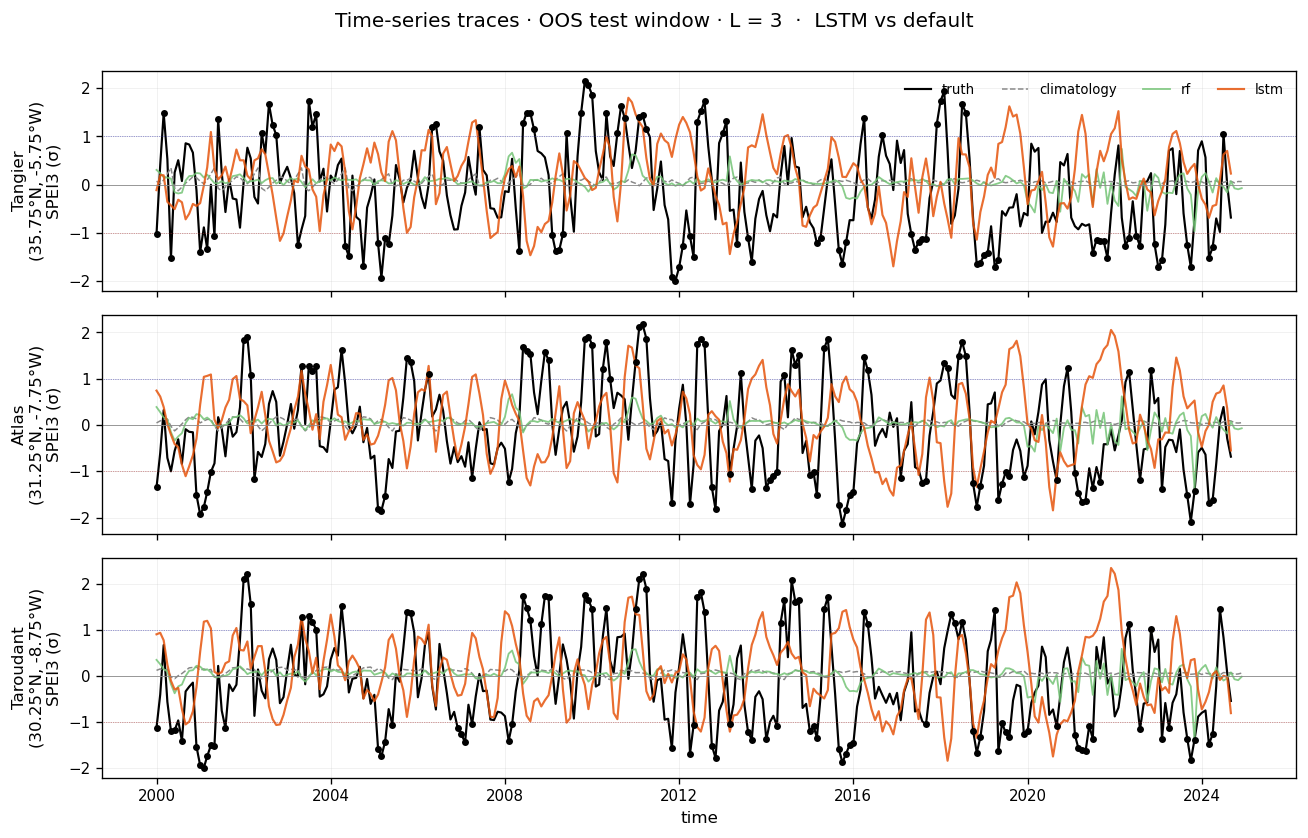

In [10]:
from collections import OrderedDict

CELLS = OrderedDict([
    ('Tangier',   (35.76, -5.83)),
    ('Atlas',     (31.50, -7.50)),
    ('Taroudant', (30.47, -8.88)),
])

def _nearest_cell(ds, lat, lon):
    lats = ds['lat'].values
    lons = ds['lon'].values
    i = int(np.argmin(np.abs(lats - lat)))
    j = int(np.argmin(np.abs(lons - lon)))
    return i, j, float(lats[i]), float(lons[j])

L_TRACE = HEADLINE_LEAD

if lstm_available and TABULAR_BEST_BY_MSSS is not None:
    fig, axes = plt.subplots(len(CELLS), 1, figsize=(11, 2.3 * len(CELLS)), sharex=True)
    if len(CELLS) == 1:
        axes = [axes]
    d = default_pred.sel(lead=L_TRACE)
    has_lstm = L_TRACE in LSTM_LEADS_OK
    l = lstm_pred.sel(lead=L_TRACE) if has_lstm else None
    time_arr = pd.DatetimeIndex(d['time'].values)
    for ax, (cell_name, (lat, lon)) in zip(axes, CELLS.items()):
        i, j, lat_use, lon_use = _nearest_cell(d, lat, lon)
        truth = d['truth'].values[:, i, j]
        clim  = d['pred_climatology'].values[:, i, j]
        tab   = d[f'pred_{TABULAR_BEST_BY_MSSS}'].values[:, i, j]

        ax.plot(time_arr, truth, color='k', lw=1.3, label='truth')
        ax.plot(time_arr, clim,  color='#888', lw=0.9, ls='--', label='climatology')
        ax.plot(time_arr, tab,   color=MODEL_COLORS[TABULAR_BEST_BY_MSSS], lw=1.1,
                alpha=0.85, label=TABULAR_BEST_BY_MSSS)
        if has_lstm:
            lstm_v = l['pred_lstm'].values[:, i, j]
            ax.plot(time_arr, lstm_v, color=MODEL_COLORS['lstm'], lw=1.3, alpha=0.85, label='lstm')
        # Highlight extreme months on the truth
        extreme = np.abs(truth) > 1.0
        ax.scatter(time_arr[extreme], truth[extreme], s=10, color='k', zorder=5)
        ax.axhline(0, color='#888', linewidth=0.5)
        ax.axhline(-1, color='#aa3333', linewidth=0.4, linestyle=':')
        ax.axhline(1, color='#3333aa', linewidth=0.4, linestyle=':')
        ax.set_ylabel(f'{cell_name}\n({lat_use:.2f}°N, {lon_use:.2f}°W)\nSPEI3 (σ)')
        ax.grid(alpha=0.25, linewidth=0.4)
        if cell_name == list(CELLS)[0]:
            ax.legend(loc='upper right', ncol=4, frameon=False, fontsize=8)
    axes[-1].set_xlabel('time')
    note = '' if has_lstm else f'  (LSTM unusable at L={L_TRACE} — diverged)'
    fig.suptitle(_ttl(f'Time-series traces · OOS test window · L = {L_TRACE}{note}'), y=1.005, fontsize=12)
    fig.tight_layout()
    _save(fig, 'fig08_timeseries_traces')
else:
    print('Fig 8 skipped (LSTM file or best-tabular reference unavailable).')


## Fig 9 — Distribution of predictions vs truth at L = 6

KDE comparison at the longest lead (L = 6) — where the signal-to-noise ratio
is lowest and tabular models are most prone to regression-to-the-mean.
Specifically overlays the LSTM and **Lasso** distributions (Lasso being the
simplest sparse-linear tabular baseline, and the one most prone to predicting
near zero under L1 shrinkage).

A model that "plays it safe" will have a tall narrow density around 0.0 —
collapsing the distribution. The truth distribution sets the right shape;
LSTM should be closer to truth in the tails (`|y| > 1`) if the weighted-MSE
training did its job.


wrote  results/figures/12_lstm_vs_default/fig09_kde_at_L6.{pdf,png}


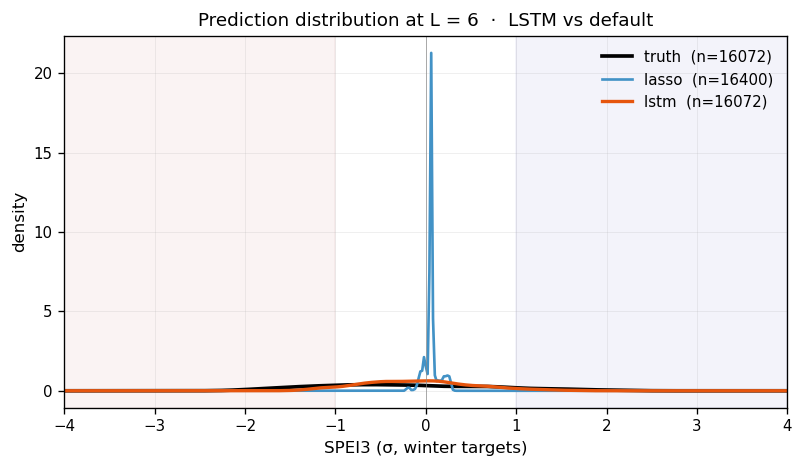

In [11]:
from scipy.stats import gaussian_kde

KDE_LEAD = 6
SUPPORT = np.linspace(-4.0, 4.0, 401)

def _flat_finite_winter(ds, var_name):
    """Flatten the winter slice's variable, drop NaN."""
    w = _winter_slice(ds)
    arr = w[var_name].values.ravel()
    return arr[np.isfinite(arr)]

def _safe_kde(arr, support):
    """gaussian_kde, but returns None when arr is too small / degenerate
    (scipy raises on n<2 OR on zero-variance inputs)."""
    if len(arr) < 2 or np.ptp(arr) == 0:
        return None
    try:
        return gaussian_kde(arr)(support)
    except Exception as e:
        print(f'  [warn] KDE failed: {e}')
        return None

if KDE_LEAD in leads:
    fig, ax = plt.subplots(figsize=(6.8, 4.0))
    d6 = default_pred.sel(lead=KDE_LEAD)

    truth_flat = _flat_finite_winter(d6, 'truth')
    lasso_flat = _flat_finite_winter(d6, 'pred_lasso')

    kde_truth = _safe_kde(truth_flat, SUPPORT)
    kde_lasso = _safe_kde(lasso_flat, SUPPORT)

    if kde_truth is not None:
        ax.plot(SUPPORT, kde_truth, color='k', lw=2.2,
                label=f'truth  (n={len(truth_flat)})')
    if kde_lasso is not None:
        ax.plot(SUPPORT, kde_lasso, color=MODEL_COLORS['lasso'], lw=1.6,
                label=f'lasso  (n={len(lasso_flat)})')

    note = ''
    if lstm_available and KDE_LEAD in LSTM_LEADS_OK:
        l6 = lstm_pred.sel(lead=KDE_LEAD)
        lstm_flat = _flat_finite_winter(l6, 'pred_lstm')
        kde_lstm = _safe_kde(lstm_flat, SUPPORT)
        if kde_lstm is not None:
            ax.plot(SUPPORT, kde_lstm, color=MODEL_COLORS['lstm'], lw=2.0,
                    label=f'lstm  (n={len(lstm_flat)})')
        else:
            note = f'  (LSTM has only {len(lstm_flat)} finite winter values — skipping)'
    elif lstm_available:
        note = f'  (LSTM unusable at L={KDE_LEAD} — diverged)'

    # Shaded regions for |y|>1 (the extreme bins the weighted MSE penalises).
    ax.axvspan(-4, -1, color='#aa3333', alpha=0.06)
    ax.axvspan( 1,  4, color='#3333aa', alpha=0.06)
    ax.axvline(0, color='#888', lw=0.4)
    ax.set_xlim(-4, 4)
    ax.set_xlabel('SPEI3 (σ, winter targets)')
    ax.set_ylabel('density')
    ax.set_title(_ttl(f'Prediction distribution at L = {KDE_LEAD}{note}'))
    ax.legend(loc='upper right', frameon=False)
    ax.grid(alpha=0.3, linewidth=0.4)
    fig.tight_layout()
    _save(fig, 'fig09_kde_at_L6')
else:
    print(f'Fig 9 skipped (L = {KDE_LEAD} not present in leads).')


## Fig 10 — Generalization diagnostic (refit-train vs test RMSE, LSTM added)

Per-(model, lead) refit-train RMSE on the x-axis vs winter-pool test RMSE on
the y-axis. Points along the 1:1 line indicate the model neither memorises
the train data nor leaves systematic train-side error — the healthy regime.
Points well *below* the 1:1 line are overfitting (train RMSE much higher
than test).

Adds LSTM points if `results/lstm/logs/fold_runs.csv` carries the `train_rmse`
column. Populate that column by running
`python scripts/08_compute_lstm_train_rmse.py --exp-config configs/experiments/exp_lstm.yaml`
first.


wrote  results/figures/12_lstm_vs_default/fig10_generalization_diagnostic_with_lstm.{pdf,png}


,model,lead,train_rmse,test_rmse,gap
6,elasticnet,1,0.626,0.558,-0.067
7,elasticnet,3,0.990,0.997,0.008
8,elasticnet,6,0.987,1.009,0.022
9,lasso,1,0.624,0.552,-0.072
10,lasso,3,0.990,0.997,0.008
11,lasso,6,0.988,1.012,0.025
12,ols,1,0.626,0.570,-0.056
13,ols,3,0.985,1.000,0.015
14,ols,6,0.977,1.028,0.051
18,rf,1,0.176,0.563,0.386


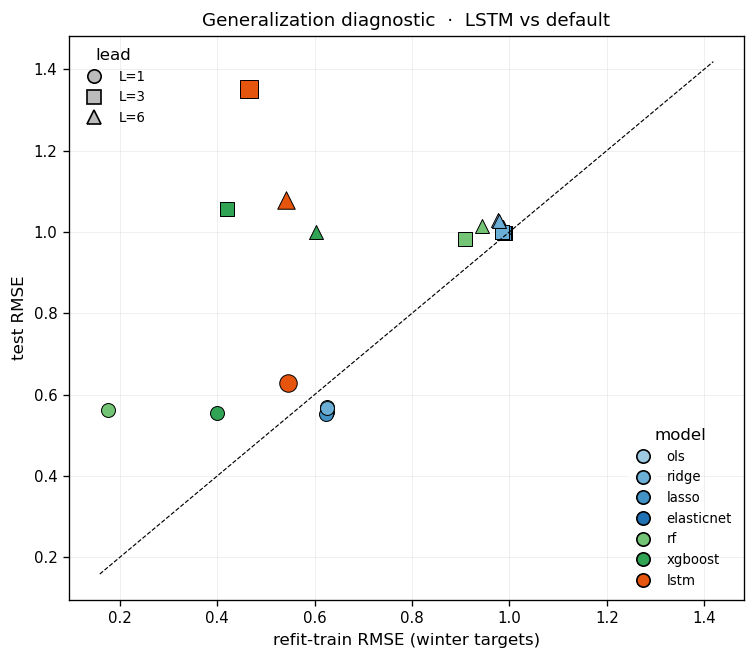

In [12]:
default_runs = pd.read_csv(RESULTS_DIR / 'logs' / 'fold_runs.csv')
lstm_runs_path = RESULTS_DIR / 'lstm' / 'logs' / 'fold_runs.csv'
lstm_runs = pd.read_csv(lstm_runs_path) if lstm_runs_path.exists() else pd.DataFrame()

# Pull pooled winter test RMSE from metrics csv.
test_rmse = (
    metr.query("metric == 'rmse' and evaluation_window == 'winter_only' and fold == 'pooled'")
        .loc[:, ['model', 'lead', 'value']]
        .rename(columns={'value': 'test_rmse'})
)

# Average train RMSE across folds per (model, lead) so we get a single point.
def _train_rmse_per_model_lead(df):
    if df.empty or 'train_rmse' not in df.columns:
        return pd.DataFrame()
    return (
        df.dropna(subset=['train_rmse'])
          .groupby(['model', 'lead'], as_index=False)['train_rmse']
          .mean()
    )

train_pts = _train_rmse_per_model_lead(default_runs)
if not lstm_runs.empty:
    train_pts = pd.concat([train_pts, _train_rmse_per_model_lead(lstm_runs)],
                           ignore_index=True)

scatter = train_pts.merge(test_rmse, on=['model', 'lead'], how='inner')
scatter = scatter[scatter['model'].isin(MODELS_FOR_COMP)].copy()

fig, ax = plt.subplots(figsize=(6.4, 5.6))
MARKERS = {1: 'o', 3: 's', 6: '^'}
for _, row in scatter.iterrows():
    color = MODEL_COLORS.get(row['model'], '#888')
    marker = MARKERS.get(int(row['lead']), 'D')
    size = 110 if row['model'] == 'lstm' else 70
    ax.scatter(row['train_rmse'], row['test_rmse'], s=size,
               color=color, marker=marker, edgecolor='k', linewidth=0.6,
               zorder=3 if row['model'] == 'lstm' else 2,
               label=f"{row['model']}  (L={int(row['lead'])})" if False else None)
# 1:1 line
if not scatter.empty:
    lo = min(scatter['train_rmse'].min(), scatter['test_rmse'].min()) * 0.9
    hi = max(scatter['train_rmse'].max(), scatter['test_rmse'].max()) * 1.05
    ax.plot([lo, hi], [lo, hi], color='k', lw=0.7, ls='--', label='1:1')

# Separate legends — model color + lead marker
from matplotlib.lines import Line2D
model_handles = [
    Line2D([0], [0], marker='o', color='w', label=m,
           markerfacecolor=MODEL_COLORS.get(m, '#888'), markersize=8, markeredgecolor='k')
    for m in MODELS_FOR_COMP if m in scatter['model'].values
]
lead_handles = [
    Line2D([0], [0], marker=MARKERS[L], color='w', label=f'L={L}',
           markerfacecolor='#bbb', markersize=8, markeredgecolor='k')
    for L in leads if L in scatter['lead'].values
]
leg1 = ax.legend(handles=model_handles, loc='lower right', frameon=False, fontsize=8, title='model')
ax.add_artist(leg1)
ax.legend(handles=lead_handles, loc='upper left', frameon=False, fontsize=8, title='lead')

ax.set_xlabel('refit-train RMSE (winter targets)')
ax.set_ylabel('test RMSE')
ax.set_title(_ttl('Generalization diagnostic'))
ax.grid(alpha=0.3, linewidth=0.4)
fig.tight_layout()
_save(fig, 'fig10_generalization_diagnostic_with_lstm')

# Inline diagnostic table
scatter.assign(gap=lambda d: d['test_rmse'] - d['train_rmse']).round(3)


## Fold-runs merge view

One row per (model × lead) summarising the fitting costs and HP settings
across the 5 folds. Useful for a supplementary table.


In [13]:
default_runs = pd.read_csv(RESULTS_DIR / 'logs' / 'fold_runs.csv')
lstm_runs_path = RESULTS_DIR / 'lstm-run2' / 'logs' / 'fold_runs.csv'
lstm_runs = pd.read_csv(lstm_runs_path) if lstm_runs_path.exists() else pd.DataFrame()

def _summarise_runs(df, experiment):
    if df.empty:
        return df
    keep = df[df['model'].isin(MODELS_FOR_COMP)].copy()
    if keep.empty:
        return keep
    agg = keep.groupby(['model', 'lead']).agg(
        n_folds=('fold', 'count'),
        n_features=('n_features_total', 'mean'),
        K_eff=('K_eff', 'mean'),
        boundary_gap=('boundary_gap', 'mean'),
        fit_seconds=('fit_duration_s', 'mean'),
        best_val=('best_val_score', 'mean'),
        best_iter=('best_iteration', 'mean'),
        n_trials=('n_trials', 'mean'),
    ).round(2).reset_index()
    agg['experiment'] = experiment
    return agg

merge = pd.concat([
    _summarise_runs(default_runs, 'default'),
    _summarise_runs(lstm_runs, 'lstm-run2'),
], ignore_index=True)

# Reorder columns for readability
cols = ['experiment', 'model', 'lead', 'n_folds', 'n_features', 'K_eff', 'boundary_gap',
        'fit_seconds', 'best_val', 'best_iter', 'n_trials']
merge = merge[[c for c in cols if c in merge.columns]]
merge.to_csv(FIG_DIR / 'fold_runs_merge.csv', index=False)
print(f'wrote  {(FIG_DIR / "fold_runs_merge.csv").relative_to(ROOT)}')
merge.sort_values(['lead', 'experiment', 'model']).reset_index(drop=True)


wrote  results/figures/12_lstm_vs_default/fold_runs_merge.csv


,experiment,model,lead,n_folds,n_features,K_eff,boundary_gap,fit_seconds,best_val,best_iter,n_trials
0,default,elasticnet,1,5,59.6,5.0,8.0,113.27,-0.45,NaN,35.0
1,default,lasso,1,5,59.6,5.0,8.0,20.33,-0.45,NaN,13.0
2,default,ols,1,5,59.6,5.0,8.0,1.46,NaN,NaN,0.0
3,default,rf,1,5,59.6,5.0,8.0,2398.64,-0.44,NaN,40.0
4,default,ridge,1,5,59.6,5.0,8.0,16.20,-0.46,NaN,13.0
5,default,xgboost,1,5,59.6,5.0,8.0,96.11,-0.40,146.0,40.0
6,default,elasticnet,3,5,59.6,5.0,10.0,59.40,-0.97,NaN,35.0
7,default,lasso,3,5,59.6,5.0,10.0,18.36,-0.97,NaN,13.0
8,default,ols,3,5,59.6,5.0,10.0,1.19,NaN,NaN,0.0
9,default,rf,3,5,59.6,5.0,10.0,1949.69,-1.02,NaN,40.0


## Fig 11 — Per-fold training loss vs epoch

Per (lead × fold) training-loss curves from the saved LSTMModel objects.
Loads each `results/lstm/models/lstm_lead{L}_fold{F}.joblib` and pulls the
`fit_state_.train_loss_history` attribute populated by `fit_tensors`.

The y-axis is the **actual training criterion** — weighted MSE
(`w = 1 + alpha · 1{|y|>1}`, `alpha=3`) — so absolute magnitudes are not
directly comparable to test RMSE. The shape matters more than the level:
a curve that is still descending at the right edge of the panel says
`max_epochs=80` was binding (the model wanted more training time); a
curve that flattens early says the model has converged and patience is
the right knob to tune.

During the per-fold refit the pipeline disables early-stopping
(val_slice is `None`), so the val curve is absent on these saved models.
Add validation data back to `_fit_lstm_combo` if you want val curves in
addition to train.


wrote  results/figures/12_lstm_vs_default/fig11_lstm_training_curves.{pdf,png}
wrote  results/figures/12_lstm_vs_default/lstm_training_curves_diag.csv


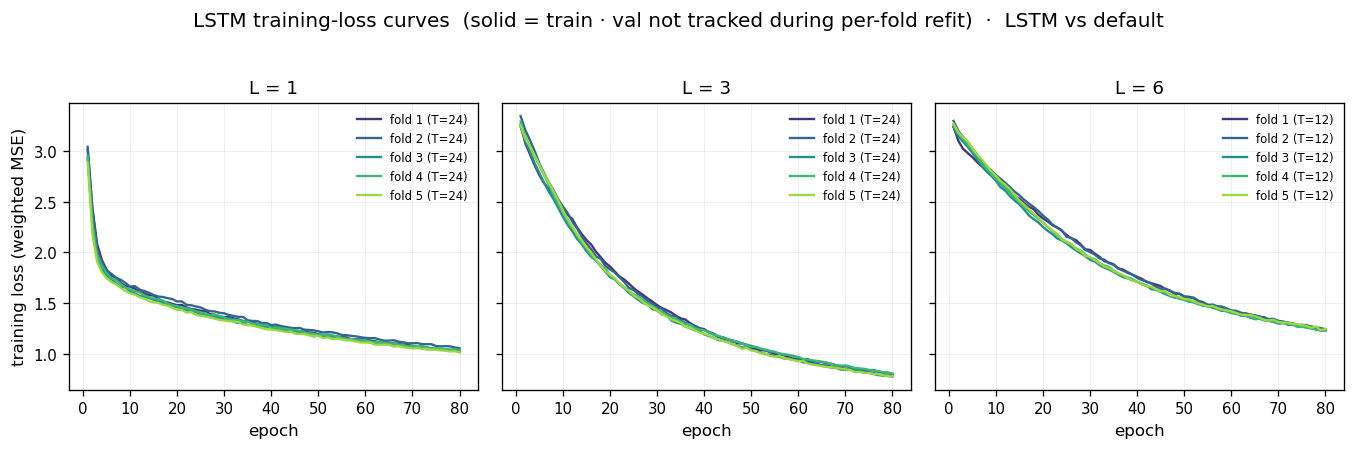

In [14]:
import joblib

LSTM_MODELS_DIR = RESULTS_DIR / 'lstm' / 'models'

def _load_fit_history(path):
    """Return (train_history, val_history, T) or None if the file is unreadable."""
    if not path.exists() or path.stat().st_size < 64:
        return None
    try:
        m = joblib.load(path)
    except Exception:
        return None
    state = getattr(m, 'fit_state_', None)
    if state is None:
        return None
    return (
        np.asarray(state.train_loss_history, dtype=float),
        np.asarray(state.val_loss_history, dtype=float),
        int(getattr(m, 'sequence_length', -1)),
    )

curves = {}        # (lead, fold) -> (train, val, T)
for L in leads:
    for fold in range(1, 6):
        p = LSTM_MODELS_DIR / f'lstm_lead{L}_fold{fold}.joblib'
        h = _load_fit_history(p)
        if h is not None:
            curves[(L, fold)] = h

if not curves:
    print('Fig 11 skipped — no readable LSTM model files. '
          'Re-run scripts/07_run_lstm.py with the pickle fix in place, then '
          're-execute this notebook.')
else:
    fold_colors = plt.cm.viridis(np.linspace(0.15, 0.85, 5))
    fig, axes = plt.subplots(1, n_leads, figsize=(3.8 * n_leads, 3.6), sharey=True)
    if n_leads == 1:
        axes = [axes]
    any_val = False
    for c, L in enumerate(leads):
        ax = axes[c]
        for fold in range(1, 6):
            h = curves.get((L, fold))
            if h is None:
                continue
            train_h, val_h, T = h
            epochs = np.arange(1, len(train_h) + 1)
            ax.plot(epochs, train_h, color=fold_colors[fold - 1], lw=1.4,
                    label=f'fold {fold} (T={T})')
            # Overlay val curve if any non-NaN values present
            val_finite = np.isfinite(val_h)
            if val_finite.any():
                any_val = True
                ax.plot(epochs[val_finite], val_h[val_finite],
                        color=fold_colors[fold - 1], lw=0.9, ls='--', alpha=0.7)
        ax.set_xlabel('epoch')
        if c == 0:
            ax.set_ylabel('training loss (weighted MSE)')
        ax.set_title(f'L = {L}')
        ax.grid(alpha=0.3, linewidth=0.4)
        ax.legend(loc='upper right', fontsize=7, frameon=False)
    note = '  (solid = train · dashed = val)' if any_val else '  (solid = train · val not tracked during per-fold refit)'
    fig.suptitle(_ttl('LSTM training-loss curves' + note), y=1.03, fontsize=12)
    fig.tight_layout()
    _save(fig, 'fig11_lstm_training_curves')

    # Diagnostic table: did each (lead, fold) hit max_epochs?
    rows = []
    for (L, fold), (train_h, val_h, T) in curves.items():
        rows.append({
            'lead': L, 'fold': fold, 'T': T,
            'epochs_run': len(train_h),
            'final_train_loss': float(train_h[-1]),
            'min_train_loss':   float(train_h.min()),
            'min_at_epoch':     int(np.argmin(train_h)) + 1,
            'still_descending': bool(
                len(train_h) >= 5 and (train_h[-1] < train_h[-5])
            ),
        })
    diag = pd.DataFrame(rows).sort_values(['lead', 'fold']).reset_index(drop=True)
    diag.to_csv(FIG_DIR / 'lstm_training_curves_diag.csv', index=False)
    print(f'wrote  {(FIG_DIR / "lstm_training_curves_diag.csv").relative_to(ROOT)}')
    diag


## Wrap-up

Headline-table dump for quick reference. Pooled winter-only metrics for every
model in this comparison.

In [15]:
summary = (
    win_pool.query("metric in @METRICS_ORDER")
    .pivot_table(index=['model', 'lead'], columns='metric', values='value')
    .reindex(METRICS_ORDER, axis=1)
    .round(3)
    .reindex([(m, L) for m in MODELS_FOR_COMP for L in leads])
)
summary.to_csv(FIG_DIR / 'summary_table.csv')
print(f'wrote  {(FIG_DIR / "summary_table.csv").relative_to(ROOT)}')
summary

wrote  results/figures/12_lstm_vs_default/summary_table.csv


metric            rmse    mae  pearson_r    acc  msss_vs_climatology
model      lead                                                     
ols        1     0.570  0.458      0.806  0.809                0.672
           3     1.000  0.832     -0.001  0.032                0.001
           6     1.028  0.863      0.014  0.087                0.012
ridge      1     0.567  0.456      0.808  0.811                0.675
           3     0.999  0.831      0.004  0.039                0.004
           6     1.026  0.862      0.019  0.095                0.015
lasso      1     0.552  0.448      0.820  0.824                0.692
           3     0.997  0.828     -0.088  0.012                0.007
           6     1.012  0.849      0.050  0.235                0.042
elasticnet 1     0.558  0.453      0.816  0.820                0.685
           3     0.997  0.828     -0.101  0.006                0.006
           6     1.009  0.847      0.044  0.213                0.047
rf         1     0.563  0.466      0.812  0.815                0.680
           3     0.983  0.809      0.079  0.110                0.035
           6     1.014  0.851      0.040  0.160                0.038
xgboost    1     0.554  0.457      0.817  0.821                0.690
           3     1.056  0.862     -0.083 -0.068               -0.113
           6     1.000  0.834      0.138  0.214                0.066
lstm       1     0.629  0.501      0.777  0.780                0.602
           3     1.351  1.110     -0.120 -0.106               -0.815
           6     1.079  0.898      0.146  0.173               -0.084